In [1]:
# Load libraries and set up environment
import os 
import sys
import importlib
import datetime
import numpy as np
import pandas as pd
import anndata as ad    
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import gffutils
import anndata as ad
import scanpy as sc 

# Ensure CUDA is available and if not use CPU
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device found")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device.type == "cuda":
    torch.set_default_tensor_type(torch.cuda.FloatTensor)

# Set seed for reproducibility
torch.manual_seed(0)

# Configure plotting styles
sns.set_theme()
sc.set_figure_params(figsize=(7, 7), frameon=True, dpi=80, facecolor='white')

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

Torch version: 2.4.1.post300
CUDA available: True
CUDA device count: 3
CUDA device name: NVIDIA L40S
Using device: cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


In [96]:
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.LeafletFA as LeafletFA
import BetaDirichletFactor.differential_splicing as ds
import BetaDirichletFactor.utils as utils
import visualization.IsovizPy as ja
import evaluations.cost_correlation_assign as cca

# Reload custom modules
importlib.reload(LeafletFA)
importlib.reload(ds)
importlib.reload(utils)

Torch Version: 2.4.1.post300
CUDA Version: 12.0


<module 'BetaDirichletFactor.utils' from '/gpfs/commons/home/kisaev/Leaflet-private/src/BetaDirichletFactor/utils.py'>

In [3]:
# Anndata file input file path 
ATSE_anndata_file="/gpfs/commons/groups/knowles_lab/Karin/TMS_MODELING/DATA_FILES/BRAIN_ONLY/02112025/TMS_Anndata_ATSE_counts_with_waypoints_20250211_171237.h5ad"
ATSE_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/ATSEfiles/TMS_atse_file_unanno_also_2025-01-30_19-24-18.txt.gz"

# Define directory where output files should be saved 
output_dir="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/" 
# Make a directory for the output files inside the output directory with today's date, inside of that make a directory for the run with the current time
date=datetime.datetime.now().strftime("%Y-%m-%d")
time=datetime.datetime.now().strftime("%H-%M-%S")
output_dir = os.path.join(output_dir, date, time)
os.makedirs(output_dir, exist_ok=True)
print(f"All outputs will be saved in {output_dir}")

All outputs will be saved in /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/ATSEmap/output/2025-02-14/17-26-28


In [4]:
db = gffutils.FeatureDB("/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/gencodeVM19", keep_order=True)

In [5]:
# Load splicing anndata file along with the ATSE annotation file (both obtained using upstream processing within LeafletFA framework)
adata = ad.read_h5ad(ATSE_anndata_file)
atses = pd.read_csv(ATSE_file, sep="\t")

In [6]:
# Convert string age group to integer
adata.obs["age_group"] = adata.obs["age"].str.replace("m", "").astype(int)

### Initialize and train the LeafletFA model!

In [7]:
# Set up some useful params 
input_conc = None #torch.tensor(np.inf) # can also set as torch.tensor(np.inf) for binomial likelihood or None (beta-binomial likelihood will be used)
junc_specific_prior = False # set to True if you want to use a junc-specific prior (a set of a,b shape params for each junction) or False to learn one set of a,b shape params for all junctions
K = 30
waypoints_use = True # make sure waypoint for PSI and PHI for specified K are included in the anndata object 
num_inits = 2
cell_type_column = "cell_type_grouped"
linear_regression_columns = ["age_group"]

In [8]:
# Let's initialize the LeafletFA class 
leaflet_model = LeafletFA.LeafletFA(adata=adata, K=K, junc_specific_prior = junc_specific_prior, waypoints_use=waypoints_use, 
                           input_conc_prior = input_conc, num_epochs=100, print_epochs=30, 
                           ELBO_num_particles=5, 
                           lr=0.5, gamma=0.05, num_samples=500)

# Convert AnnData into PyTorch tensors for model training 
leaflet_model.from_anndata()

Taking in the AnnData object with 19942 cells and 76811 junctions.
Processing AnnData on cuda


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/storage.py:48: FutureWarning: AnnData previously had undefined behavior around matrices of type <class 'scipy.sparse._coo.coo_matrix'>.In 0.12, passing in this type will throw an error. Please convert to a supported type.Continue using for this minor version at your own risk.
  warnings.warn(msg, FutureWarning)


Random seeds: [664, 4912]
Training LeafletFA with 2 initializations.
Input concentration prior: None
Junction-specific prior: False
Initial K to learn: 30
Initializing variational parameters with pre-defined PSI and PHI matrices!
Shape of PSI_init is torch.Size([30, 76811])
Shape of PHI_init is torch.Size([19942, 30])
-------------------------------------------------
Initialization #1 with seed 664
-------------------------------------------------
Training in progress for 100 epochs!
Epoch 0: Loss = 370579735.11663747
Epoch 30: Loss = 198924889.18700063
Epoch 60: Loss = 185279391.20623916
Epoch 90: Loss = 183898562.18517777
Training completed after 100 epochs with loss: 183737227.9481107
No output directory specified, skipping loss plot save.
Computing summary statistics for initialization #1
-------------------------------------------------
Initialization #2 with seed 4912
-------------------------------------------------
Training in progress for 100 epochs!
Epoch 0: Loss = 362686662.

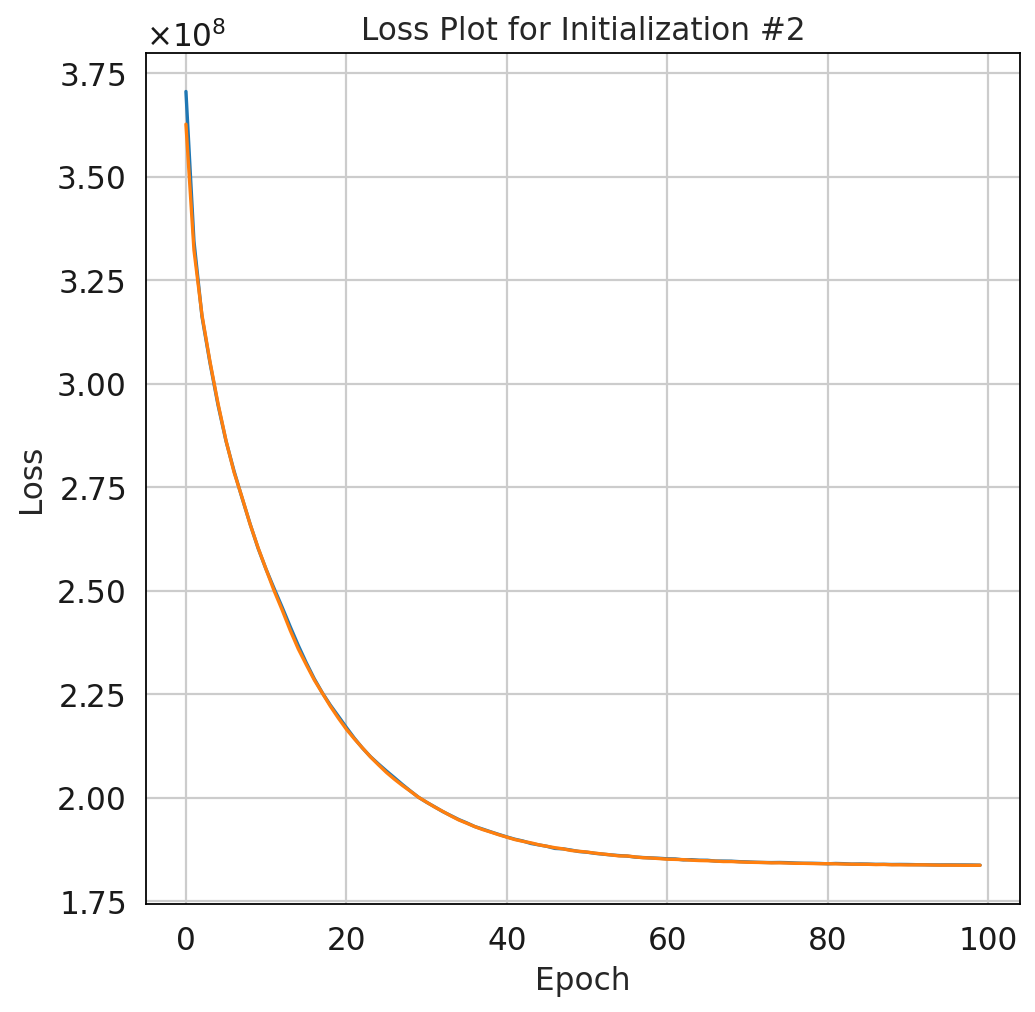

In [9]:
# Train the model 
leaflet_model.train(num_initializations=num_inits)

In [10]:
# Get the best initialization and extract all the latent variables at this initialization
# If you want the latent variables from a different initialization, you can pass the index of that initialization to the get_all_variables() function
leaflet_model.get_all_variables()

The best initialization was 1 with an ELBO of 183720375.1616542
Extracting all variables from initialization #1
Extracting PSI variational parameters...
Extracting the learned beta-binomial concentration (is applicable)...
Extracting the latent representation, C x K matrix of factor activities...
Extracting the learned Pi vector...


In [11]:
LEAFLETFA_LATENT_KEY = "X_leafletFA"
adata.obsm[LEAFLETFA_LATENT_KEY] = leaflet_model.assign_post # assign_post is the posterior assignment cell-factor activity matrix 

sc.pp.neighbors(adata, use_rep=LEAFLETFA_LATENT_KEY)
sc.tl.umap(adata)

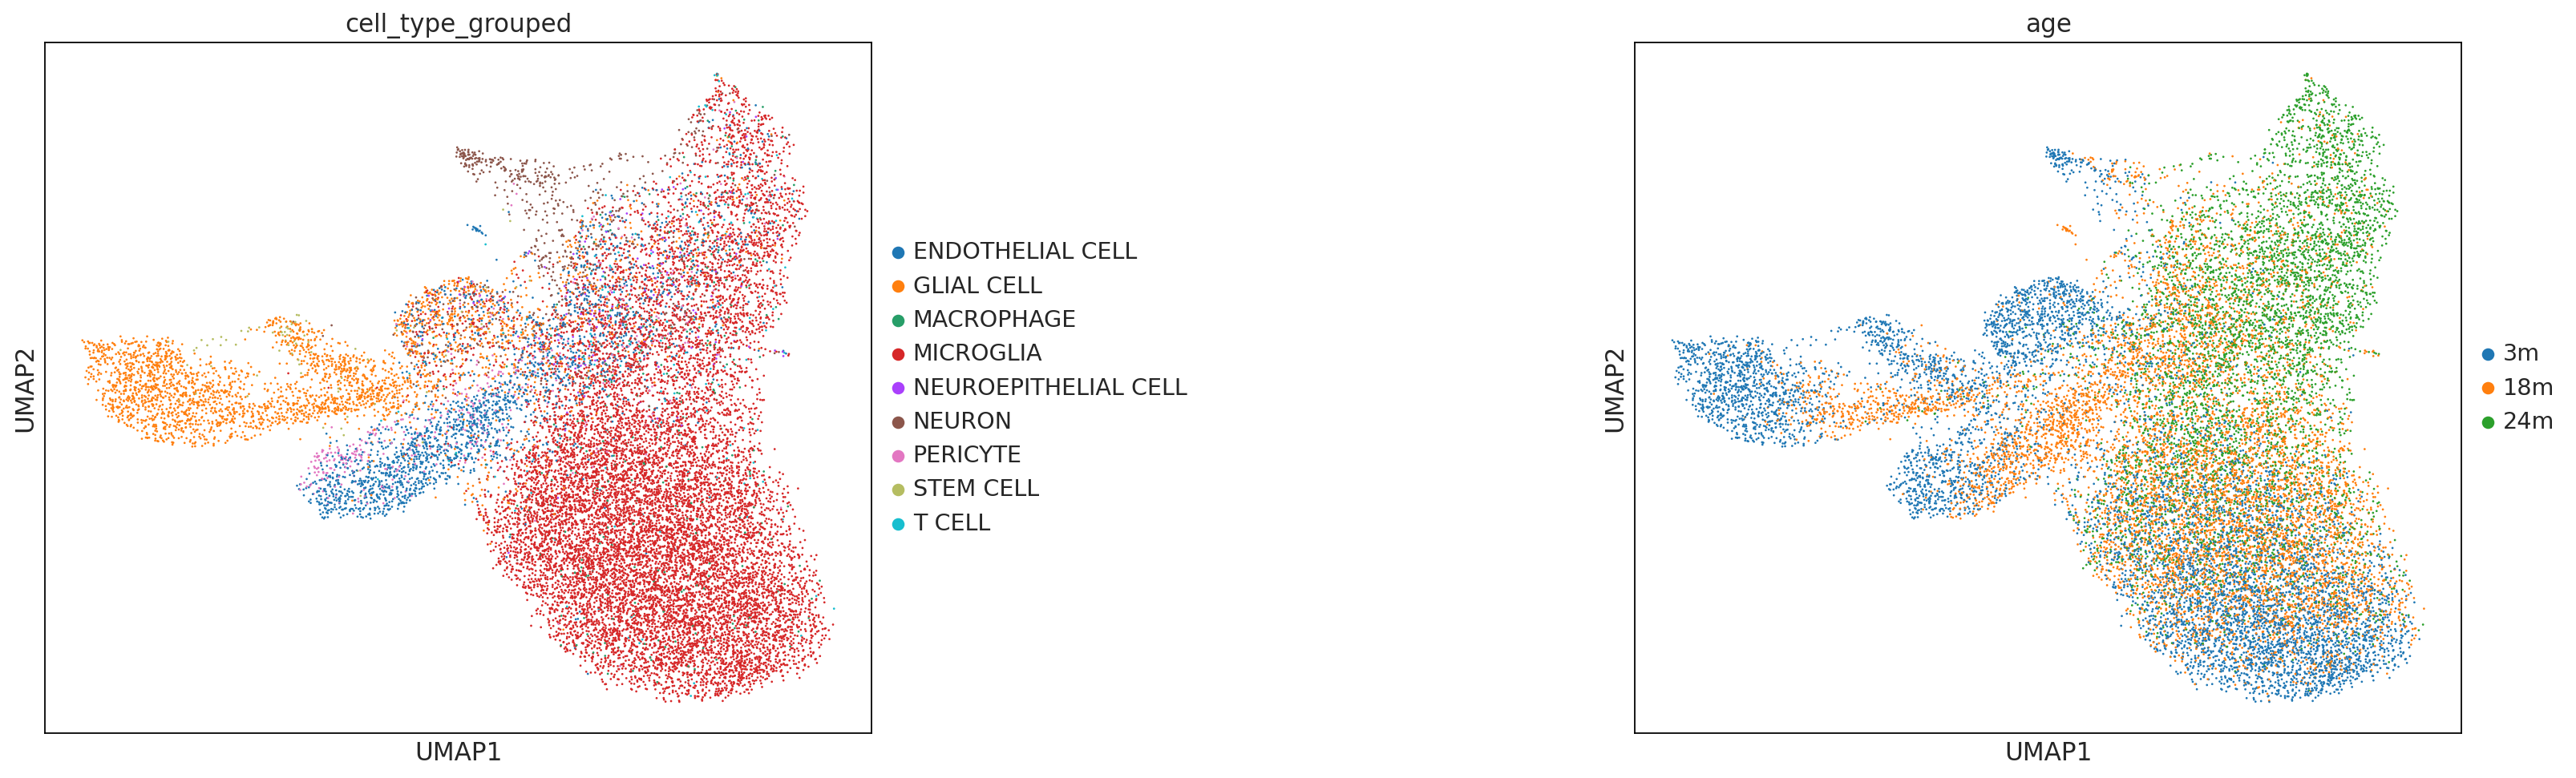

In [12]:
sc.pl.umap(adata, color=["cell_type_grouped", "age"], wspace=0.75)

Initialization 1 vs Initialization 2: Matched pairs [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29)]
Assignment Correlation Report:
Average Pairwise Correlation: 0.9944
Median Pairwise Correlation: 0.9944
Minimum Pairwise Correlation: 0.9944



/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


<Figure size 560x560 with 0 Axes>

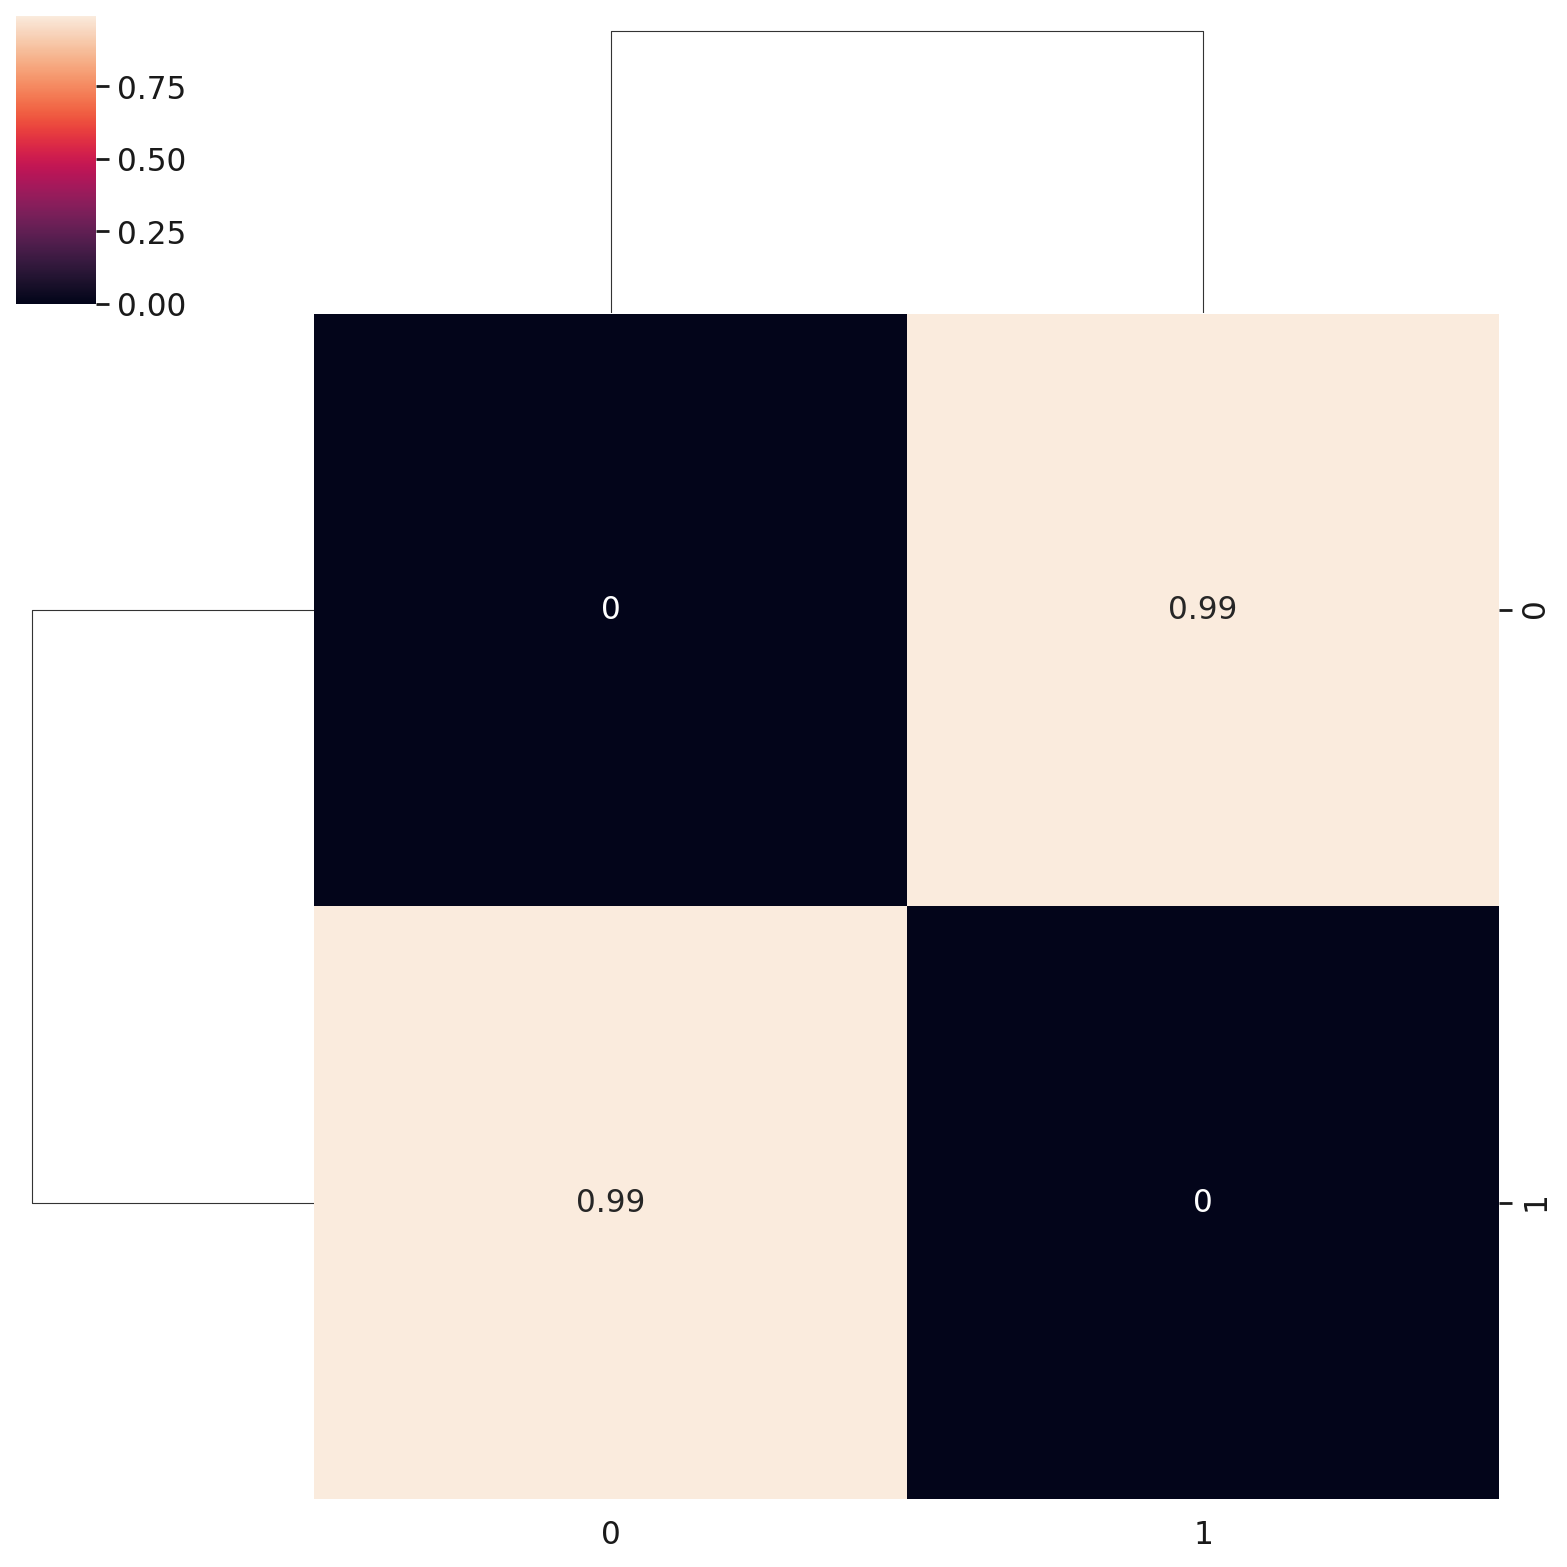

In [13]:
# let's look at the results 
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in leaflet_model.latent_results]

# Calculate correlations between initializations if more than 2 
if num_inits > 1:
    avg_corr, median_corr, min_corr = utils.calculate_and_plot_correlations(assign_matrices)
else: 
    avg_corr, median_corr, min_corr = None, None, None  # Set default values when there's only one initialization

In [14]:
# Prune K: note this updates all the latent variables in the model to only include estimates for the pruned K
leaflet_model.prune_K()

The K before pruning is 30
The K after pruning is 13
Upating K to 13 in the LeafletFA object.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


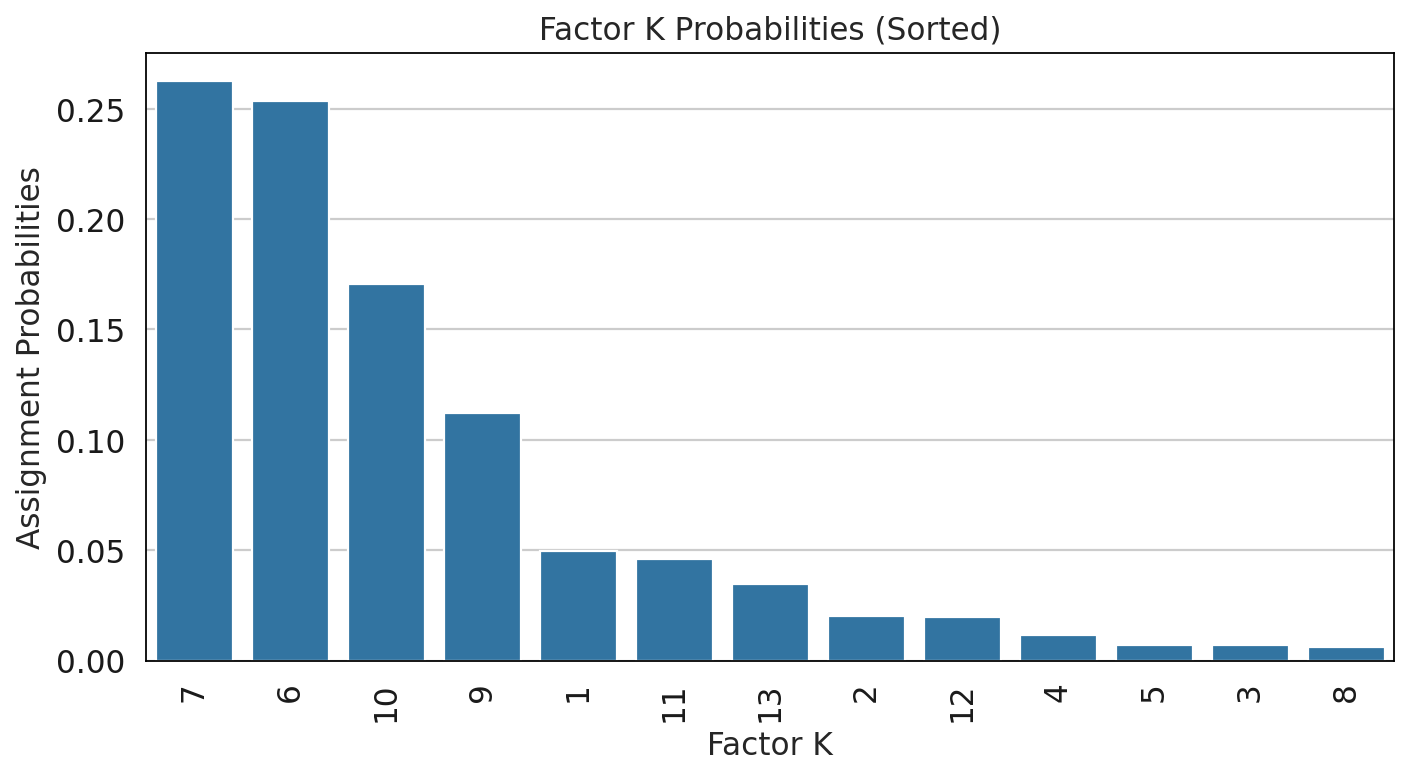

In [15]:
pi_df = pd.DataFrame(leaflet_model.pi, columns=["factor_assignment_probabilities"])
pi_df["factor_K"] = pi_df.index+1

# Sort by factor_assignment_probabilities in descending order
pi_df = pi_df.sort_values(by="factor_assignment_probabilities", ascending=False)

# Make sorted barplot
plt.figure(figsize=(10, 5))
sns.barplot(x="factor_K", y="factor_assignment_probabilities", data=pi_df, order=pi_df["factor_K"])
plt.title("Factor K Probabilities (Sorted)")
plt.xlabel("Factor K")
plt.ylabel("Assignment Probabilities")
plt.xticks(rotation=90)  # Rotate x-axis labels if many factors
plt.show()

The mean of the prior Beta distribution is 0.5025538828259578
The mean of the original Beta distribution is 0.5012072453013867


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/numpy/lib/function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


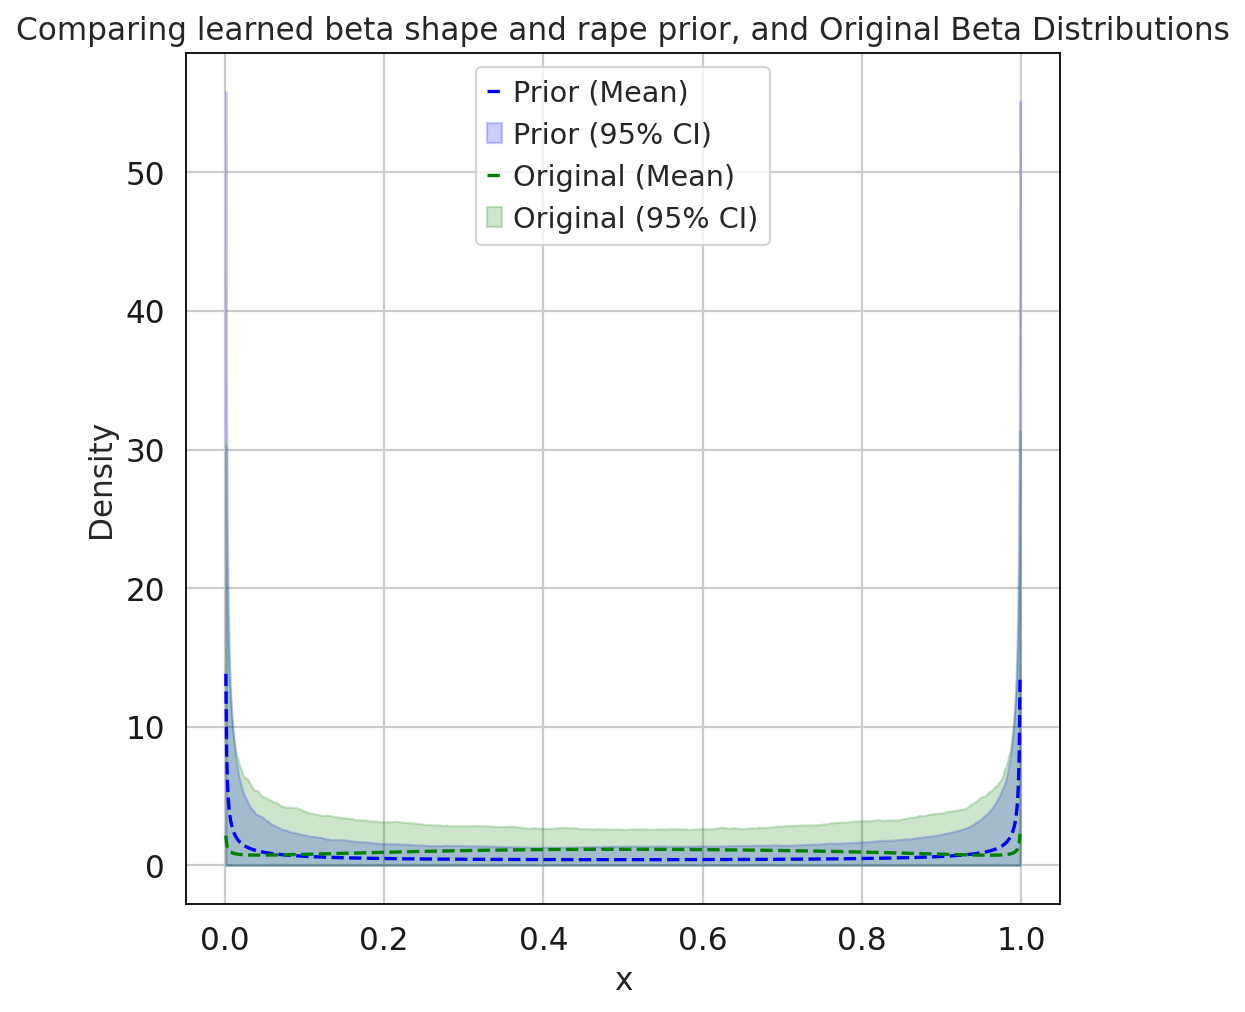

In [16]:
# Number of samples to capture variability
num_samples = 1000  

# Sample multiple shape parameters for prior and original distributions which was ~ Gamma(2,2)
a_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)
b_prior_samples = np.random.gamma(leaflet_model.a_shape, leaflet_model.a_rate, size=num_samples)

a_orig_samples = np.random.gamma(2, 2, size=num_samples)
b_orig_samples = np.random.gamma(2, 2, size=num_samples)

# Compute mean and confidence intervals for the Beta distributions
x = np.linspace(0, 1, num_samples)

# Compute PDFs for each sampled (a,b) pair
prior_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_prior_samples, b_prior_samples)])
orig_pdfs = np.array([stats.beta.pdf(x, a, b) for a, b in zip(a_orig_samples, b_orig_samples)])

# Compute the mean and 95% confidence intervals for each x
prior_mean = np.mean(prior_pdfs, axis=0)
prior_lower = np.percentile(prior_pdfs, 2.5, axis=0)
prior_upper = np.percentile(prior_pdfs, 97.5, axis=0)

orig_mean = np.mean(orig_pdfs, axis=0)
orig_lower = np.percentile(orig_pdfs, 2.5, axis=0)
orig_upper = np.percentile(orig_pdfs, 97.5, axis=0)

print(f"The mean of the prior Beta distribution is {np.mean(a_prior_samples/(a_prior_samples+b_prior_samples))}")
print(f"The mean of the original Beta distribution is {np.mean(a_orig_samples/(a_orig_samples+b_orig_samples))}")

# Plot mean prior Beta distribution with confidence interval shading
plt.plot(x, prior_mean, label="Prior (Mean)", color='blue', linestyle='dashed')
plt.fill_between(x, prior_lower, prior_upper, color='blue', alpha=0.2, label="Prior (95% CI)")

# Plot mean original Beta distribution with confidence interval shading
plt.plot(x, orig_mean, label="Original (Mean)", color='green', linestyle='dashed')
plt.fill_between(x, orig_lower, orig_upper, color='green', alpha=0.2, label="Original (95% CI)")

# Labels and legend
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.title("Comparing learned beta shape and rape prior, and Original Beta Distributions")
plt.show()

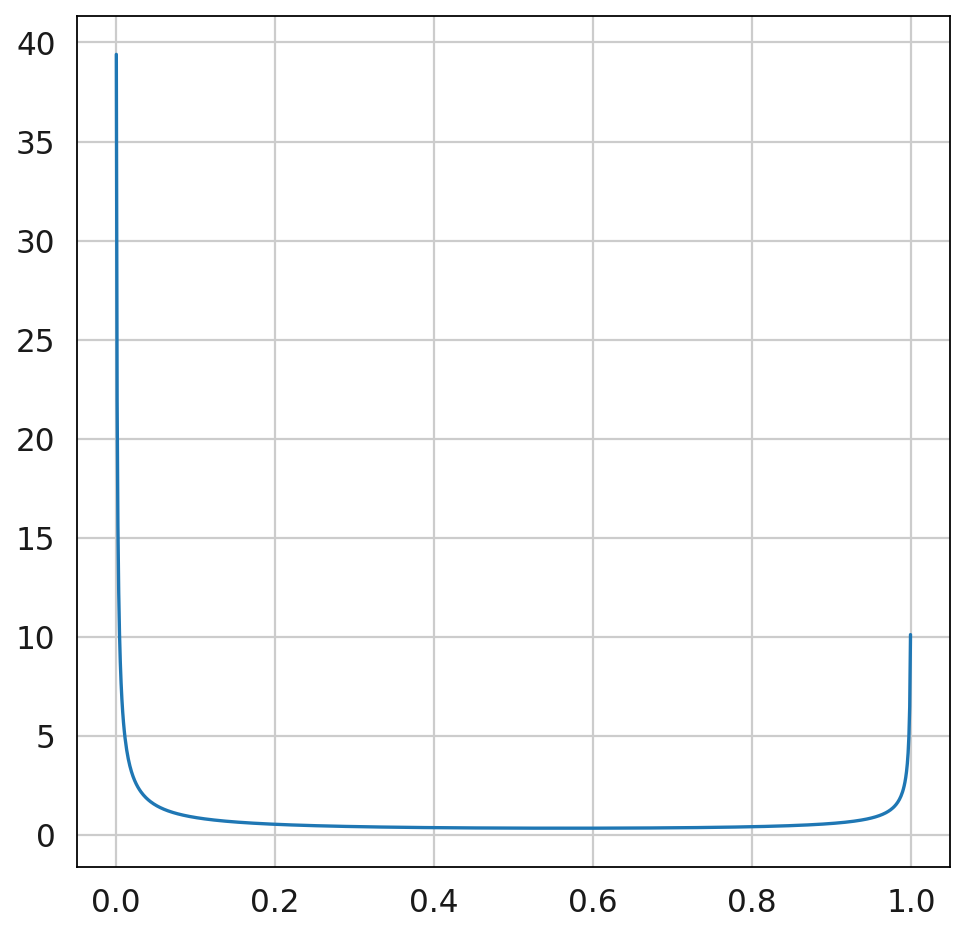

In [17]:
if junc_specific_prior:

    num_samples=100
    x = np.linspace(0, 1, num_samples)
    K = leaflet_model.K

    # Plot K Beta distributions, each corresponding to a junction's a and b
    plt.figure(figsize=(10, 6))
    for i in range(K):
        a_j = leaflet_model.a[i]
        b_j = leaflet_model.b[i]
        print(f"The mean of the {i}th factor's Beta distribution is: {a_j / (a_j + b_j)}")

        beta_pdf = stats.beta.pdf(x, a_j, b_j)
        plt.plot(x, beta_pdf, alpha=0.5)  

    # Labels and legend
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Visualization of {K} Junction-Specific Beta Distributions")
    plt.legend(loc="upper right", fontsize=8, ncol=2)  # Keep legend readable
    plt.show()

else:

    # sample from the learned prior on beta with leafletmodel.a and leafletmodel.b
    num_samples = 1000
    x = np.linspace(0, 1, num_samples)
    a = leaflet_model.a
    b = leaflet_model.b
    
    # sample from this beta distribution only one global a and b value... 
    beta_pdf = stats.beta.pdf(x, a, b)
    plt.plot(x, beta_pdf, label="Learned Beta Distribution")

In [97]:
SJ_DSS = ds.compute_z_score_dss(leaflet_model.psis_loc, leaflet_model.psis_scale, leaflet_model.pi, adata.var_names)
SJ_DSS.shape # K by J matrix let's add it to anndata 
LEAFLETFA_SJ_DSS_KEY = "SJ_DSS"
adata.varm[LEAFLETFA_SJ_DSS_KEY] = SJ_DSS

The shape of var_jk is: (13, 76811)
The length of mu_j is: 76811
The length of var_mu_j is: 76811


In [98]:
SJ_DSS

,factor_0,factor_1,factor_2,factor_3,factor_4,factor_5,factor_6,factor_7,factor_8,factor_9,...,factor_3_pvalue,factor_4_pvalue,factor_5_pvalue,factor_6_pvalue,factor_7_pvalue,factor_8_pvalue,factor_9_pvalue,factor_10_pvalue,factor_11_pvalue,factor_12_pvalue
0,0.670884,0.295378,1.289735,0.248396,0.809314,-0.345209,-0.046973,0.941238,0.249514,0.049246,...,0.803828,0.418335,7.299374e-01,0.962535,0.346583,8.029636e-01,0.960723,8.907513e-01,0.939329,0.834413
1,-0.940523,4.218236,-0.028948,-0.675996,-0.383033,4.354519,-2.002286,-0.169469,6.504635,-1.449871,...,0.499043,0.701695,1.333592e-05,0.045254,0.865428,7.788237e-11,0.147095,6.438016e-09,0.524046,0.000198
2,0.777778,-0.113377,0.782446,0.645491,0.661901,-0.160264,-0.270146,1.136015,0.022430,0.135323,...,0.518609,0.508035,8.726733e-01,0.787048,0.255950,9.821052e-01,0.892356,9.471349e-01,0.373996,0.899869
3,0.399373,0.037424,1.280442,0.486876,0.590199,-0.400093,-0.087730,1.184353,0.085732,0.361209,...,0.626346,0.555057,6.890883e-01,0.930091,0.236273,9.316794e-01,0.717944,8.074251e-01,0.639696,0.888638
4,0.329722,0.197774,3.022465,0.590576,2.327952,-0.263925,-0.380261,1.184732,0.241522,0.024098,...,0.554805,0.019915,7.918374e-01,0.703751,0.236124,8.091509e-01,0.980774,5.792901e-01,0.707917,0.096478
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76806,-0.278999,1.539997,-0.338055,-0.690860,0.755377,6.028364,-2.270335,-0.539258,-1.755415,-1.730861,...,0.489653,0.450023,1.656274e-09,0.023187,0.589709,7.918828e-02,0.083477,6.523067e-01,0.073358,0.000682
76807,0.180168,1.937047,3.757181,1.819821,0.970906,-0.166598,-0.300717,1.030140,0.140976,0.082270,...,0.068786,0.331595,8.676864e-01,0.763630,0.302944,8.878886e-01,0.934432,9.401011e-01,0.784737,0.706748
76808,0.903499,-0.351850,0.234924,0.469685,1.103340,-0.309105,-0.064714,0.200829,0.019521,-0.022539,...,0.638580,0.269879,7.572419e-01,0.948402,0.840833,9.844256e-01,0.982018,8.788466e-01,0.666474,0.517764
76809,-1.075880,1.158160,0.303768,0.913816,0.902938,8.177151,-1.570183,1.355139,-1.182410,-1.550475,...,0.360814,0.366559,3.330669e-16,0.116372,0.175373,2.370431e-01,0.121027,5.106328e-02,0.546465,0.002520


In [75]:
SJ_DSS[0]
# sort SJ_DSS but keep track of the original indices
sorted_indices = np.argsort(SJ_DSS[0])[::-1]
sorted_indices

array([53003, 18771, 25045, ..., 23834, 28871, 25044])

In [84]:
leaflet_model.all_samples["psi"].shape

torch.Size([500, 30, 76811])

In [ ]:
def plot_latent_psi(model, psi_latent, junction_idx):

    # Simulated tensor (500 samples, 30 factors, 76811 junctions)
    psi_latent = model.all_samples["psi"]  # Replace with actual sampled tensor

    # Compute mean PSI per factor for each junction (K x J)
    psi_means = psi_latent.mean(dim=0).numpy()  # Shape (30, 76811)

    psi_values = psi_latent[:, :, junction_idx]  # Shape: (500, 30)

    # Convert to Pandas DataFrame for easier manipulation
    df = pd.DataFrame(psi_values.numpy(), columns=[f"Factor {k}" for k in range(30)])

    # Convert wide-format data (500 rows, 30 columns) to long-format for ANOVA
    melted_df = df.melt(var_name="Factor", value_name="PSI")

    # Set a modern style
    sns.set_style("whitegrid")

    # Create the boxplot
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="Factor", y="PSI", data=melted_df, palette="coolwarm", inner="box", scale="width")
    
    # Improve readability
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel("Latent Factors", fontsize=12)
    plt.ylabel("PSI Values", fontsize=12)
    plt.title(f"PSI Distribution Across Latent Factors (Junction {junction_idx})", fontsize=14, fontweight="bold")
    
    # Remove unnecessary borders
    sns.despine()

    # Show the plot
    plt.show()

In [ ]:
psis_df = compute_and_plot_albf(pruned_psis_mus, pruned_psis_loc, pruned_psi_learned, pruned_pi, new_K)
psis_df.rename(columns={i: f"cell_state_{i}" for i in range(new_K)}, inplace=True)
psis_df = psis_df.set_index("junction_id_index")  # Ensure it uses the correct index

In [ ]:
# make sure adata.var_names are integers not "1" strings 
adata.var_names = adata.var_names.astype(int)
adata.var = pd.concat([adata.var, psis_df], axis=1)    
# for all columns that are cell_state_k in adata.var, get max value "max_cell_state_usage"
adata.var["max_cell_state_usage"] = adata.var[[col for col in adata.var.columns if "cell_state_" in col]].max(axis=1)
adata.obs["cell_type"] = adata.obs[cell_type_column]

In [ ]:
# Create cell type colors
cell_types_series = pd.Series(adata.obs.cell_type.astype(str).values)
cell_types_unique = np.unique(cell_types_series)
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types_series.map(cell_type_dict).values

In [ ]:
# Create age colors 
age_series = pd.Series(adata.obs.age.astype(str).values)
age_unique = np.unique(age_series)
age_colors = sns.color_palette("tab20", len(age_unique))
age_dict = dict(zip(age_unique, age_colors))
age_colors = age_series.map(age_dict).values

In [ ]:
# Run UMAP first on embedding! 
reducer = umap.UMAP()
embedding = reducer.fit_transform(pruned_assign_post)

In [ ]:
# Scatter plot for UMAP
plt.scatter(embedding[:, 0], embedding[:, 1], s=3, c=cell_colors, alpha=0.5)
    
# Add legend
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
# Scatter plot for UMAP
plt.scatter(embedding[:, 0], embedding[:, 1], s=3, c=age_colors, alpha=0.4)
    
# Add legend
legend_handles = [mpatches.Patch(color=color, label=age) for age, color in age_dict.items()]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left')

In [ ]:
def calculate_silhouette_score(assign_post, cell_types):
    """Calculates silhouette score for the factor assignments."""
    return silhouette_score(assign_post, cell_types)

In [ ]:
cell_tye_silhouette = calculate_silhouette_score(pruned_assign_post, adata.obs.cell_type_grouped.values)

In [ ]:
age_silhouette = calculate_silhouette_score(pruned_assign_post, adata.obs.age.values)

In [ ]:
print(f"Silhouette score for cell types: {cell_tye_silhouette}")
print(f"Silhouette score for age: {age_silhouette}")

In [ ]:
# Make sorted barplot of learned pruned_pi vector 
pruned_pi_og = pruned_pi.copy()
pruned_pi = pd.Series(pruned_pi)
pruned_pi.index = [f"factor_{i+1}" for i in range(len(pruned_pi))]
pruned_pi = pruned_pi.sort_values(ascending=False)

# plot sorted pruned_pi
plt.figure(figsize=(8, 5))
plt.bar(pruned_pi.index, pruned_pi.values)
plt.xticks(rotation=45)
plt.ylabel("Factor weight")
plt.title("Learned factor weights")
plt.show()

In [ ]:
# Add ALBF scores to adata.var 
adata.var["FW-DSS"] = compute_confidence_weighted_fw_dss(adata.var, pruned_pi_og)
adata.var["FW-DSS"].hist(bins=100)

In [ ]:
adata.var["FW-DSS-sigmoid"] = 1 / (1 + np.exp(-adata.var["FW-DSS"]))
adata.var["FW-DSS-sigmoid"].hist(bins=100)

In [ ]:
# plot FW-DSS score across annotation_status of junctions violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(x="annotation_status", y="FW-DSS", data=adata.var)
plt.title("FW-DSS scores across junction annotation status")
plt.show()


In [ ]:
# plot FW-DSS score across annotation_status of junctions violinplot
plt.figure(figsize=(8, 5))
sns.violinplot(x="annotation_status", y="max_cell_state_usage", data=adata.var)
plt.title("Max inferred PSI across cell states K")
plt.show()


In [ ]:
# how to find ATSE or splice junction markers of each cell state 
# sort by FW-DSS but for junctions that dont have both under annotation_status

adata.var.sort_values(by="FW-DSS", ascending=False)

In [ ]:
junc = 38425
plot_junc_dists(adata.var, junc, pruned_pi_og)

In [ ]:
# find all the junctions in junc's ATSE event_id
event_id = adata.var.loc[junc, "event_id"]
juncs_in_event = adata.var[adata.var["event_id"] == event_id].junction_id_index.values
print(juncs_in_event)

In [ ]:
juncs = atses[atses["event_id"]==event_id]
juncs = juncs.merge(adata.var[adata.var["event_id"] == event_id][["junction_id", "FW-DSS"]])
juncs["usage_ratio"] = juncs["FW-DSS"].astype(float)
juncs["Cluster"] = juncs["event_id"]

splice_junctions = ja.convert_junction_ids(juncs)
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})

print(f"The unique transcripts mapping to junctions in this ATSE event are: {unique_transcripts}")
print(juncs[["junction_id", "annotation_status", "FW-DSS"]].sort_values(by="FW-DSS", ascending=False))

# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)
region_start, region_end = ja.determine_region_boundaries(splice_junctions)

In [ ]:
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start+200, region_end-200, base_width=12, trans_height=0.9, show_usage=True, show_junc_lines=False)

In [ ]:
# let's say we want to compare junction usage across factors to find the most differentially used junctions across factors... (assuming that some factors are associated with aging or cell types)
# lets look at factor 0
ref_fact = 0
alt_fact = 1

# get pi usage at factor 0
pi_usage_ref = pruned_pi_og[ref_fact]
cell_factor_ref = pruned_assign_post[:, ref_fact]
psi_factor_ref = pruned_psi_learned[ref_fact]

# get pi usage at factor 0
pi_usage_alt = pruned_pi_og[alt_fact]
cell_factor_alt = pruned_assign_post[:, alt_fact]
psi_factor_alt = pruned_psi_learned[alt_fact]

In [ ]:
# sampled PSI from guide .
leaflet_object.all_samples["psi"][0].max()

In [ ]:
from scipy.stats import f_oneway
from scipy.special import entr
from tqdm import tqdm 

# Simulated tensor (500 samples, 30 factors, 76811 junctions)
psi_latent = leaflet_object.all_samples["psi"]  # Replace with actual sampled tensor

# Compute mean PSI per factor for each junction (K x J)
psi_means = psi_latent.mean(dim=0).numpy()  # Shape (30, 76811)
print(psi_means.shape)

# ANOVA test per junction
p_values = []
effect_sizes = []
entropies = []
perplexities = []

# Iterate over each junction and perform ANOVA test on samples from each factor (500 by 30)
for junc in tqdm(range(psi_latent.shape[2])):
    
    # Compute entropy (adding small epsilon to prevent log(0) errors)
    psi_probs = psi_means[:, junc] / (np.sum(psi_means[:, junc]) + 1e-10)  # Normalize
    entropy = -np.sum(psi_probs * np.log(psi_probs + 1e-10))  # Shannon entropy
    entropies.append(entropy)

    # Compute perplexity
    perplexity = np.exp(entropy)
    perplexities.append(perplexity)

    # Compute effect size η² (variance explained by factor)
    ss_between = np.var(psi_means[:, junc], ddof=1) * psi_means.shape[0]  # Between-group variance
    ss_total = np.var(psi_latent[:, :, junc].numpy(), ddof=1) * psi_latent.numel()  # Total variance
    eta_squared = ss_between / (ss_total + 1e-10)  # Avoid divide-by-zero
    effect_sizes.append(eta_squared)

# Convert results to NumPy arrays
p_values = np.array(p_values)
effect_sizes = np.array(effect_sizes)
entropies = np.array(entropies)
perplexities = np.array(perplexities)  # NEW perplexity array


In [ ]:
import torch
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def run_anova_psi(psi_latent, junction_idx=0):
    """
    Performs ANOVA to compare PSI distributions across latent factors for a given junction
    and visualizes the distributions using a styled boxplot.

    Parameters:
    - psi_latent (torch.Tensor): Tensor of shape (500, 30, num_junctions), containing PSI estimates.
    - junction_idx (int): Index of the junction to analyze.

    Returns:
    - ANOVA F-statistic and p-value.
    """
    # Extract PSI values for the given junction (500 samples x 30 factors)
    psi_values = psi_latent[:, :, junction_idx]  # Shape: (500, 30)

    # Convert to Pandas DataFrame for easier manipulation
    df = pd.DataFrame(psi_values.numpy(), columns=[f"Factor {k}" for k in range(30)])

    # Convert wide-format data (500 rows, 30 columns) to long-format for ANOVA
    melted_df = df.melt(var_name="Factor", value_name="PSI")

    # Set a modern style
    sns.set_style("whitegrid")

    # Create the boxplot
    plt.figure(figsize=(12, 6))
    sns.violinplot(x="Factor", y="PSI", data=melted_df, palette="coolwarm", inner="box", scale="width")
    
    # Improve readability
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel("Latent Factors", fontsize=12)
    plt.ylabel("PSI Values", fontsize=12)
    plt.title(f"PSI Distribution Across Latent Factors (Junction {junction_idx})", fontsize=14, fontweight="bold")
    
    # Remove unnecessary borders
    sns.despine()

    # Show the plot
    plt.show()

    # Run ANOVA: Compare PSI distributions across 30 factors
    groups = [df[col] for col in df.columns]  # List of 30 PSI distributions
    f_stat, p_value = stats.f_oneway(*groups)

    print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_value:.4e}")
    
    return f_stat, p_value

In [ ]:
adata.var.sort_values("FW-DSS")

In [ ]:
f_stat, p_value = run_anova_psi(psi_latent, junction_idx=62191)

In [ ]:
# Example usage
f_stat, p_value = run_anova_psi(psi_latent, junction_idx=38425)

In [ ]:
junc = 38425
plot_junc_dists(adata.var, junc, pruned_pi_og)

In [ ]:
results_df.sort_values("Perplexity")